# Exploratory Data Analysis

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\annus\Cleaned_Employee_HR.csv")

# Convert binary target to readable labels for visualizations
df['churn_label'] = df['left'].map({1: 'Left', 0: 'Stayed'})

In [8]:
# --------------------------------------------------------------------------------------------------------------------------------
# 1. OVERALL ATTRITION METRICS
# --------------------------------------------------------------------------------------------------------------------------------
total_employees = len(df)
churn_count = df['left'].sum()
churn_rate = (churn_count / total_employees) * 100

print(f"=== HR ATTRITION OVERVIES ===")
print(f"Total Employees: {total_employees}")
print(f"Employees Left: {churn_count} ({churn_rate:.2f}%")
print(f"Employees Stayed: {total_employees - churn_count} ({100 - churn_rate:.2f}%\n")

=== HR ATTRITION OVERVIES ===
Total Employees: 14999
Employees Left: 3571 (23.81%
Employees Stayed: 11428 (76.19%



In [9]:
print(df.columns.tolist())

['emp_id', 'satisfaction', 'evaluation', 'number_of_projects', 'average_monthly_hours', 'time_spent_company', 'work_accident', 'promotion', 'department', 'salary_inr', 'left', 'churn_label']


In [10]:
# -----------------------------------------------------------------------------------------------------------------------------
# 2. KEY STATISTICAL; COMPARISONS (LEFT vs STAYED)
# -----------------------------------------------------------------------------------------------------------------------------
metrics = ['satisfaction', 'evaluation', 'average_monthly_hours', 'time_spent_company', 'salary_inr']
comparison_df = df.groupby('churn_label')[metrics].mean().T
comparison_df['% Difference '] = ((comparison_df['Left'] - comparison_df['Stayed']) / comparison_df['Stayed'])

print("=== AVERAGE METRICS COMPARISON ===")
print(comparison_df.round(2))
print("\n" + "="*50 + "\n")

=== AVERAGE METRICS COMPARISON ===
churn_label                Left    Stayed  % Difference 
satisfaction               0.44      0.67          -0.34
evaluation                 0.72      0.72           0.00
average_monthly_hours    207.42    199.06           0.04
time_spent_company         3.88      3.38           0.15
salary_inr             46430.11  67840.03          -0.32




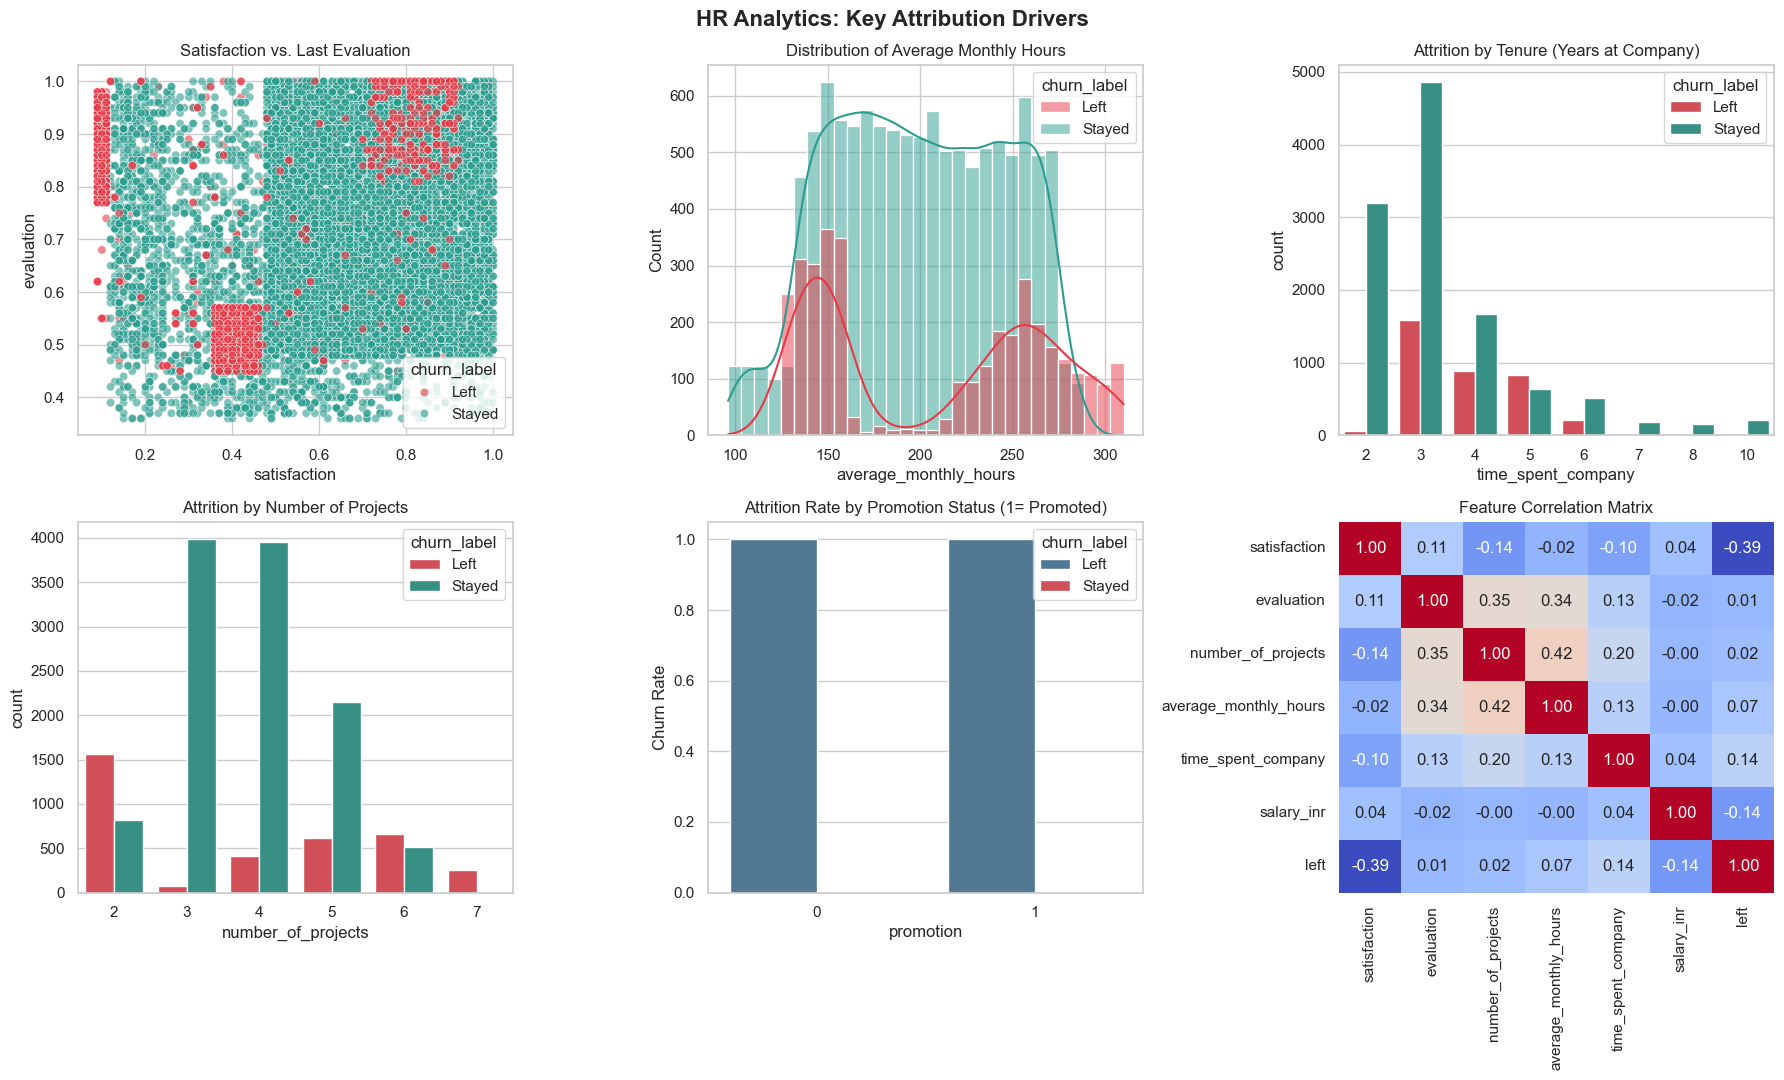

In [11]:
# -----------------------------------------------------------------------------------------------------------------------------
# 3. VISUALIZATIONS
# -----------------------------------------------------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('HR Analytics: Key Attribution Drivers', fontsize=16, fontweight='bold')

# A. Satisfaction vs Evaluation (Scatter Plot)
sns.scatterplot(
    data=df, x='satisfaction', y='evaluation', hue='churn_label', palette={'Left': '#E63946', 'Stayed': '#2A9D8F'}, alpha=0.6, ax=axes[0, 0])
axes[0, 0].set_title('Satisfaction vs. Last Evaluation')

# B. Monthly Hours Distribution (KDE / Histogram)
sns.histplot(
    data=df, x='average_monthly_hours', hue='churn_label', palette={'Left': '#E63946', 'Stayed': '#2A9D8F'}, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Average Monthly Hours')

# C. Tenure / Time Spent at Company (Bar Plot)
sns.countplot(
    data=df, x='time_spent_company', hue='churn_label', palette={'Left': '#E63946', 'Stayed': '#2A9D8F'}, ax=axes[0, 2])
axes[0, 2].set_title('Attrition by Tenure (Years at Company)')

# D. Number of Projects vs Attrition
sns.countplot(
    data=df, x='number_of_projects', hue='churn_label', palette={'Left': '#E63946', 'Stayed': '#2A9D8F'}, ax=axes[1, 0])
axes[1, 0].set_title('Attrition by Number of Projects')

# E. Promotion in Lat 5 Years vs Attrition Rate
sns.barplot(
    data=df, x='promotion', y='left', hue='churn_label', palette=['#457B9D', '#E63946'], ax=axes[1, 1])
axes[1, 1].set_title('Attrition Rate by Promotion Status (1= Promoted)')
axes[1, 1].set_ylabel('Churn Rate')

# F. Correlation Heatmap
num_cols = ['satisfaction', 'evaluation', 'number_of_projects', 'average_monthly_hours', 'time_spent_company', 'salary_inr', 'left']
sns.heatmap(
    df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',cbar=False, ax=axes[1, 2])
axes[1, 2].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()